In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

In [2]:
(X_train,y_train),(X_test,y_test)=cifar10.load_data()

print(X_train.shape)
print(y_train.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
(50000, 32, 32, 3)
(50000, 1)


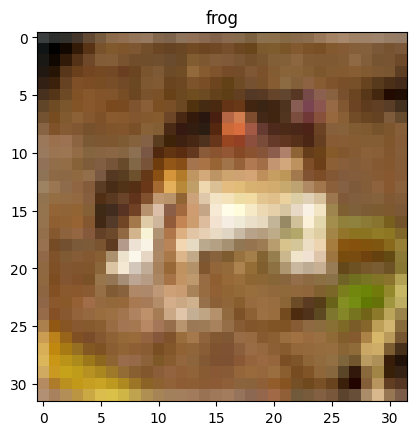

In [3]:
labels = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

plt.imshow(X_train[0])
plt.title(labels[y_train[0][0]])
plt.show()

In [4]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [5]:
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

In [6]:
model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(32,32,3)
    )
)

model.add(MaxPooling2D((2,2)))

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(
    128,
    activation='relu'
))

model.add(Dense(
    10,
    activation='softmax'
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 52s 142ms/step - accuracy: 0.4517 - loss: 1.5396 - val_accuracy: 0.5358 - val_loss: 1.3052
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 50s 141ms/step - accuracy: 0.5779 - loss: 1.2079 - val_accuracy: 0.6102 - val_loss: 1.1170
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 80s 136ms/step - accuracy: 0.6302 - loss: 1.0649 - val_accuracy: 0.6252 - val_loss: 1.0760
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 82s 137ms/step - accuracy: 0.6585 - loss: 0.9835 - val_accuracy: 0.6726 - val_loss: 0.9725
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 51s 144ms/step - accuracy: 0.6807 - loss: 0.9222 - val_accuracy: 0.6688 - val_loss: 0.9605
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 82s 145ms/step - accuracy: 0.7067 - loss: 0.8514 - val_accuracy: 0.6862 - val_loss: 0.9202
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 79s 138ms/step - accuracy: 0.7238 - loss: 0.8024 - val_accuracy: 0.6976 - val_loss: 0.8902
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 81s 135ms/step - accuracy: 0.7406 - loss: 0

In [9]:
loss,accuracy = model.evaluate(
    X_test,
    y_test
)

print("Accuracy =",accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6978 - loss: 0.9030
Accuracy = 0.6977999806404114


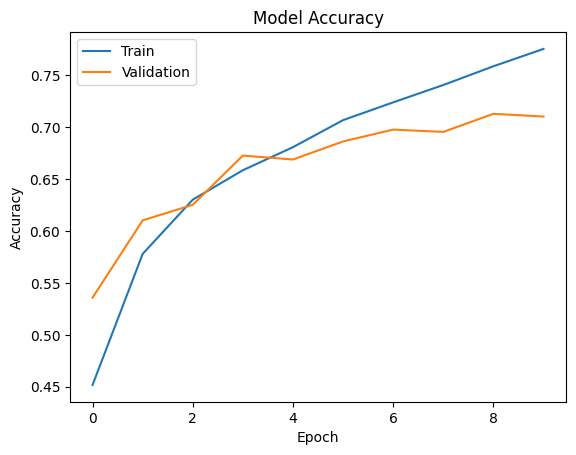

In [10]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train','Validation'])

plt.show()

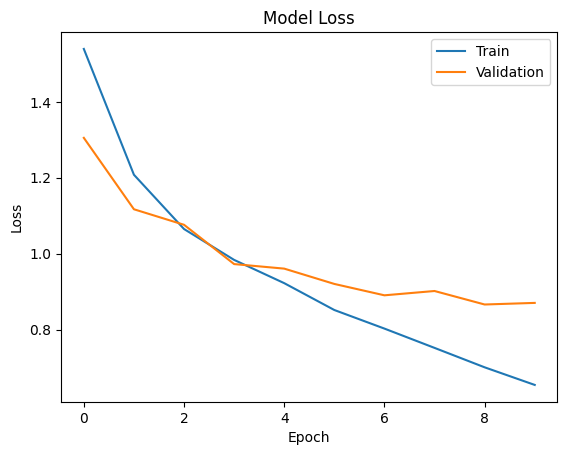

In [11]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train','Validation'])

plt.show()

In [12]:
pred = model.predict(X_test)

pred_class = np.argmax(pred, axis=1)

real_class = np.argmax(y_test, axis=1)

print("Predict :", pred_class[:10])
print("Real    :", real_class[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step
Predict : [3 8 8 2 4 6 5 6 3 1]
Real    : [3 8 8 0 6 6 1 6 3 1]
